In [1]:
module('load', 'pytorch/gpu-cuda-12.1/2.2.0')

Loading pytorch/gpu-cuda-12.1/2.2.0
  Loading requirement: cuda/12.1 cudnn/8.9.2


In [2]:
import numpy as np
from shared_utils import units
import astropy.units as u
from shared_utils import recursive_to_tensor
import torch
from deep_learning import ResNet50
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(num_classes=2).to(device)
#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth", map_location=device)
#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochFFT/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-04_13-33-39.pth", map_location=device)
#ckpt = torch.load("BEST_checkpoint.pth", map_location=device) # good inteferometric

ckpt = torch.load("../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth", map_location=device) #Euclid noise RUN 1
other_ckpt1 = torch.load("../trained_classifiers/RUN2clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_23-19-17.pth", map_location = device) #Euclid noise RUN 2
other_ckpt3 = torch.load("sensitivity_maps/BEST_checkpoint.pth", map_location=device)  #Interferometric noise RUN 1
other_ckpt4 = torch.load("../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth", map_location=device) # Interferometric noise RUN 2

#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochFFT/3_min_mass_10e8_6/checkpoints/checkpoint_epoch_5_2025-08-04_12-42-32.pth", map_location=device)

state_dict = ckpt["model_state_dict"]

new_state = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # remove `module.` if present
    new_state[name] = v

# 4) load weights into your model (don’t reassign!)
missing, unexpected = model.load_state_dict(new_state, strict=False)
print("missing keys:", missing)
print("unexpected keys:", unexpected)
model.eval()

from abc import ABC, abstractmethod
class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs : torch.Tensor)-> torch.Tensor:
        # here we have imgs bacause we are intedned to always work with batches at this stage
        pass
class Normalizer(ImgLastProc):
    def __call__(self, imgs : torch.Tensor)-> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val

        return imgs
    
class AstroNormalizer(ImgLastProc):
    def __call__(self, imgs):
    # Your data is naturally zero-centered, so only scale by std
        return imgs / 4.24e-17 
    
class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)

        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs

class Normalizer(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val
        return imgs
    
from noise_applicator.noisers.base_noiser import EuclidNoiserInterfPSF, OnlyInterfPSF, EuclidNoiser

normalizer = Normalizer()
noiser= EuclidNoiser()


from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import custom_dataloader
from deep_learning.NN_models import ResNet50

test_dataset = NoNoiseDataset(
            "min_mass_10e8_6_test",
            grid_pixel_side=80,
            grid_width_arcsec=8.0,
            broadcasting=True,
            samples_used=20_000,
            upscaling=5,
)

val_clean_loader = custom_dataloader(
    test_dataset, batch_size=256
)


# then we do noiser -> normalizer -> model

missing keys: []
unexpected keys: []
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
20000


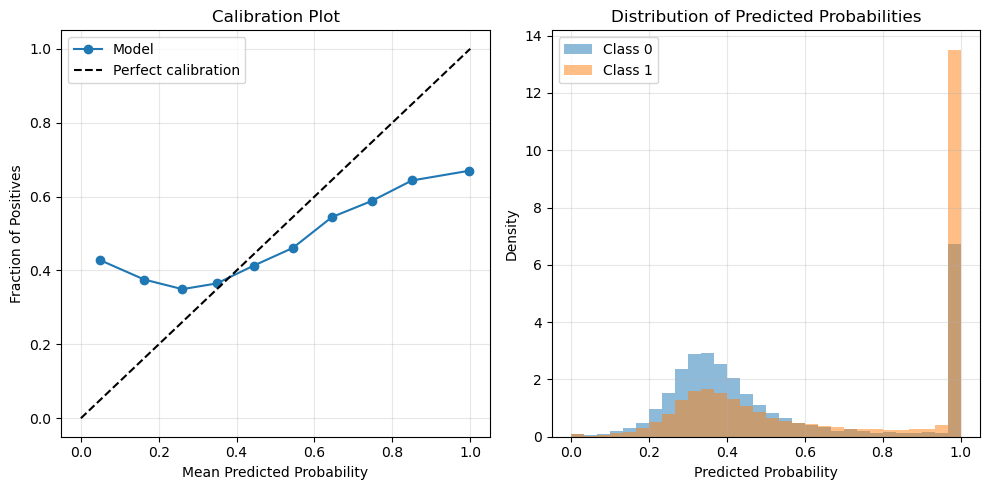

Expected Calibration Error (ECE): 0.1587


In [12]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Collect predictions and labels
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in val_clean_loader:
        imgs, labels = batch
        imgs = imgs.to(device)
        
        # Apply your preprocessing pipeline
        imgs = noiser(imgs)
        imgs = normalizer(imgs)
        
        # Get model predictions
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Calculate calibration curve
n_bins = 10
fraction_of_positives, mean_predicted_value = calibration_curve(
    all_labels, all_probs, n_bins=n_bins, strategy='uniform'
)

# Plot calibration curve
plt.figure(figsize=(10, 5))

# Calibration plot
plt.subplot(1, 2, 1)
plt.plot(mean_predicted_value, fraction_of_positives, 'o-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram of predictions
plt.subplot(1, 2, 2)
plt.hist(all_probs[all_labels == 0], bins=30, alpha=0.5, label='Class 0', density=True)
plt.hist(all_probs[all_labels == 1], bins=30, alpha=0.5, label='Class 1', density=True)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate Expected Calibration Error (ECE)
def calculate_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

ece = calculate_ece(all_labels, all_probs)
print(f"Expected Calibration Error (ECE): {ece:.4f}")


Starting calibration analysis for all 4 models...
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.
Loading test dataset...
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
1000

Evaluating Euclid Noise - Run 1...


  ECE: 0.1612

Evaluating Euclid Noise - Run 2...


  ECE: 0.1303

Evaluating Interferometric - Run 1...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1211

Evaluating Interferometric - Run 2...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1192

CALIBRATION RESULTS SUMMARY
Euclid Noise - Run 1           ECE: 0.1612
Euclid Noise - Run 2           ECE: 0.1303
Interferometric - Run 1        ECE: 0.1211
Interferometric - Run 2        ECE: 0.1192


/tmp/ipykernel_25362/197111514.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2023.03/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2023.03/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2023.03/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2023.03/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarn

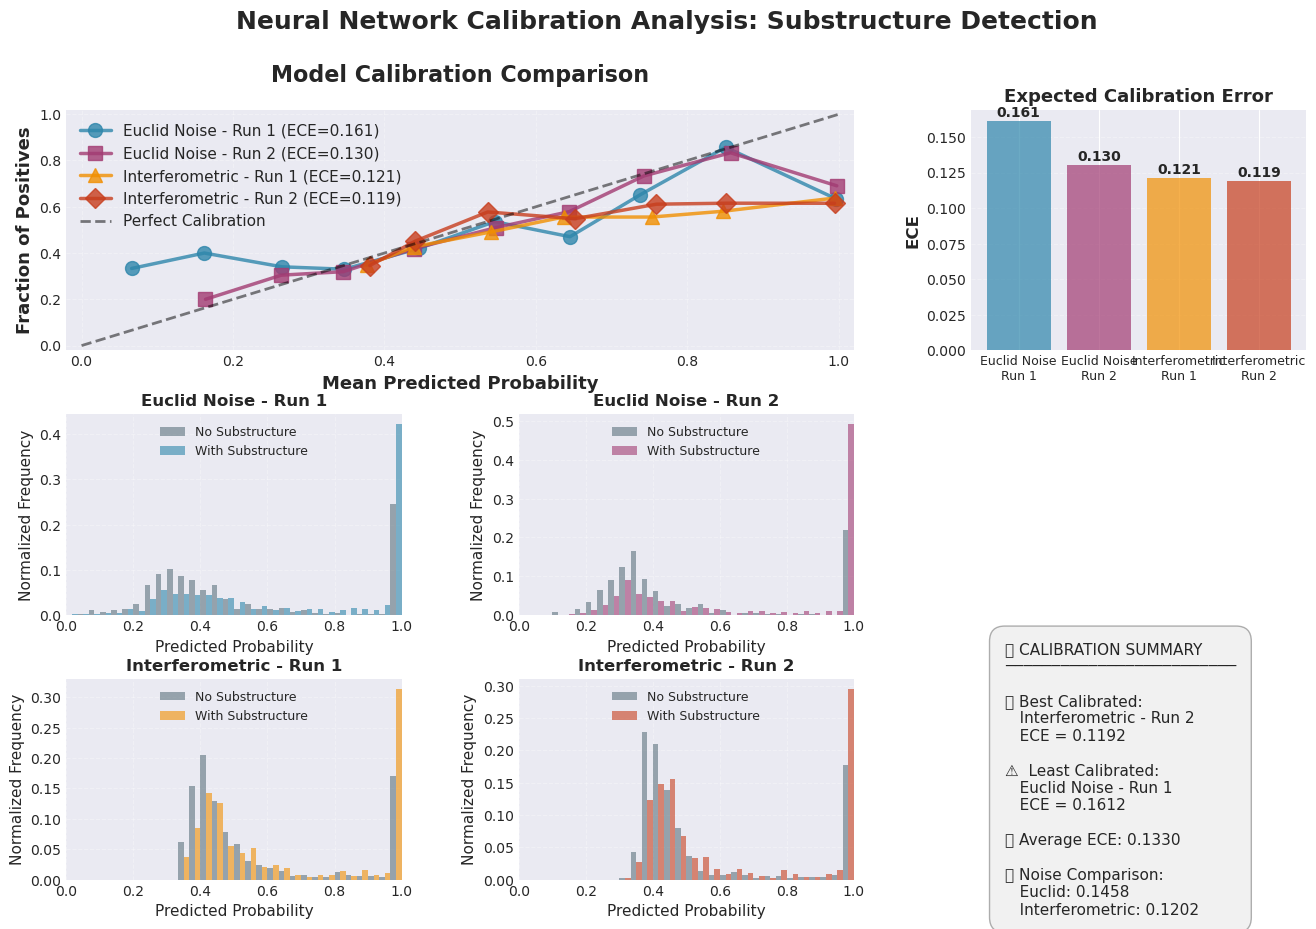

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from collections import OrderedDict
from tqdm import tqdm

# Import your modules
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import custom_dataloader
from noise_applicator.noisers.base_noiser import EuclidNoiser, OnlyInterfPSF

# Import your normalizer classes
from abc import ABC, abstractmethod

class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        pass

class Normalizer(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val
        return imgs

class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def load_model_weights(model, checkpoint_path, device):
    """Load model weights from checkpoint"""
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    
    # Remove 'module.' prefix if present
    new_state = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        new_state[name] = v
    
    # Load weights
    model.load_state_dict(new_state, strict=False)
    return model

def evaluate_model_calibration(model, dataloader, noiser, normalizer, device):
    """Evaluate a single model's calibration"""
    all_probs = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, labels = batch
            imgs = imgs.to(device)
            
            # Apply preprocessing pipeline
            imgs = noiser(imgs)
            imgs = normalizer(imgs)
            
            # Get model predictions
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Calculate calibration curve
    n_bins = 10
    fraction_of_positives, mean_predicted_value = calibration_curve(
        all_labels, all_probs, n_bins=n_bins, strategy='uniform'
    )
    
    # Calculate ECE
    ece = calculate_ece(all_labels, all_probs)
    
    return {
        'probs': all_probs,
        'labels': all_labels,
        'fraction_positives': fraction_of_positives,
        'mean_predicted': mean_predicted_value,
        'ece': ece
    }

def analyze_all_models():
    """Analyze calibration for all 4 models"""
    
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Define model configurations
    model_configs = [
        {
            'name': 'Euclid Noise - Run 1',
            'checkpoint': "../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#2E86AB',  # Blue
            'marker': 'o'
        },
        {
            'name': 'Euclid Noise - Run 2',
            'checkpoint': "../trained_classifiers/RUN2clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_23-19-17.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#A23B72',  # Purple
            'marker': 's'
        },
        {
            'name': 'Interferometric - Run 1',
            'checkpoint': "sensitivity_maps/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#F18F01',  # Orange
            'marker': '^'
        },
        {
            'name': 'Interferometric - Run 2',
            'checkpoint': "../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#C73E1D',  # Red
            'marker': 'D'
        }
    ]
    
    # Load test dataset once
    print("Loading test dataset...")
    test_dataset = NoNoiseDataset(
        "min_mass_10e8_6_test",
        grid_pixel_side=80,
        grid_width_arcsec=8.0,
        broadcasting=True,
        samples_used=1_000,
        upscaling=5,
    )
    
    dataloader = custom_dataloader(test_dataset, batch_size=256)
    
    # Store results for all models
    results = []
    
    # Evaluate each model
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        # Create and load model
        model = ResNet50(num_classes=2).to(device)
        model = load_model_weights(model, config['checkpoint'], device)
        
        # Set noiser to correct device
        config['noiser'].set_device(device)
        
        # Evaluate calibration
        result = evaluate_model_calibration(
            model, dataloader, config['noiser'], config['normalizer'], device
        )
        result['config'] = config
        results.append(result)
        
        print(f"  ECE: {result['ece']:.4f}")
    
    return results

def plot_calibration_panel(results):
    """Create a beautiful panel showing all 4 calibration results"""
    
    # Set up the figure with a modern style
    plt.style.use('seaborn-v0_8-darkgrid')
    fig = plt.figure(figsize=(16, 10))
    
    # Create a grid layout
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.35, 
                         height_ratios=[1.2, 1, 1], width_ratios=[1, 1, 1])
    
    # Main calibration plot (top left, spans 2 columns)
    ax_main = fig.add_subplot(gs[0, :2])
    
    # Plot calibration curves for all models
    for result in results:
        config = result['config']
        ax_main.plot(result['mean_predicted'], result['fraction_positives'], 
                    marker=config['marker'], markersize=10, linewidth=2.5,
                    label=f"{config['name']} (ECE={result['ece']:.3f})",
                    color=config['color'], alpha=0.8)
    
    # Add perfect calibration line
    ax_main.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect Calibration')
    
    # Styling for main plot
    ax_main.set_xlabel('Mean Predicted Probability', fontsize=13, fontweight='bold')
    ax_main.set_ylabel('Fraction of Positives', fontsize=13, fontweight='bold')
    ax_main.set_title('Model Calibration Comparison', fontsize=16, fontweight='bold', pad=20)
    ax_main.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax_main.grid(True, alpha=0.3, linestyle='--')
    ax_main.set_xlim([-0.02, 1.02])
    ax_main.set_ylim([-0.02, 1.02])
    
    # ECE Bar chart (top right)
    ax_ece = fig.add_subplot(gs[0, 2])
    ece_values = [r['ece'] for r in results]
    names = [r['config']['name'].split(' - ')[0] + '\n' + r['config']['name'].split(' - ')[1] 
             for r in results]
    colors = [r['config']['color'] for r in results]
    
    bars = ax_ece.bar(range(len(ece_values)), ece_values, color=colors, alpha=0.7)
    ax_ece.set_xticks(range(len(names)))
    ax_ece.set_xticklabels(names, fontsize=9, rotation=0)
    ax_ece.set_ylabel('ECE', fontsize=12, fontweight='bold')
    ax_ece.set_title('Expected Calibration Error', fontsize=13, fontweight='bold')
    ax_ece.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Add value labels on bars
    for bar, val in zip(bars, ece_values):
        ax_ece.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Individual probability distributions (bottom row)
    for idx, result in enumerate(results):
        if idx < 2:
            ax = fig.add_subplot(gs[1, idx])
        else:
            ax = fig.add_subplot(gs[2, idx-2])
        
        config = result['config']
        probs = result['probs']
        labels = result['labels']
        
        # Create histograms
        bins = np.linspace(0, 1, 31)
        
        # Plot for class 0
        hist0, _ = np.histogram(probs[labels == 0], bins=bins)
        hist1, _ = np.histogram(probs[labels == 1], bins=bins)
        
        # Normalize
        hist0 = hist0 / hist0.sum()
        hist1 = hist1 / hist1.sum()
        
        width = bins[1] - bins[0]
        centers = (bins[:-1] + bins[1:]) / 2
        
        ax.bar(centers - width/4, hist0, width/2, alpha=0.6, 
               label='No Substructure', color='#5D737E')
        ax.bar(centers + width/4, hist1, width/2, alpha=0.6, 
               label='With Substructure', color=config['color'])
        
        ax.set_xlabel('Predicted Probability', fontsize=11)
        ax.set_ylabel('Normalized Frequency', fontsize=11)
        ax.set_title(config['name'], fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='upper center')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim([0, 1])
    
    # Summary statistics box (bottom right)
    ax_stats = fig.add_subplot(gs[2, 2])
    ax_stats.axis('off')
    
    # Create summary text
    stats_text = "📊 CALIBRATION SUMMARY\n" + "─" * 25 + "\n\n"
    
    # Find best and worst models
    ece_vals = [(r['config']['name'], r['ece']) for r in results]
    best_model = min(ece_vals, key=lambda x: x[1])
    worst_model = max(ece_vals, key=lambda x: x[1])
    
    stats_text += f"✅ Best Calibrated:\n   {best_model[0]}\n   ECE = {best_model[1]:.4f}\n\n"
    stats_text += f"⚠️  Least Calibrated:\n   {worst_model[0]}\n   ECE = {worst_model[1]:.4f}\n\n"
    
    # Average ECE
    avg_ece = np.mean([r['ece'] for r in results])
    stats_text += f"📈 Average ECE: {avg_ece:.4f}\n\n"
    
    # Noise type comparison
    euclid_ece = np.mean([r['ece'] for r in results[:2]])
    interf_ece = np.mean([r['ece'] for r in results[2:]])
    stats_text += f"🔊 Noise Comparison:\n"
    stats_text += f"   Euclid: {euclid_ece:.4f}\n"
    stats_text += f"   Interferometric: {interf_ece:.4f}"
    
    ax_stats.text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
                 bbox=dict(boxstyle='round,pad=1', facecolor='lightgray', alpha=0.3))
    
    # Overall title
    fig.suptitle('Neural Network Calibration Analysis: Substructure Detection', 
                fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig

# Main execution
if __name__ == "__main__":
    print("Starting calibration analysis for all 4 models...")
    results = analyze_all_models()
    
    print("\n" + "="*50)
    print("CALIBRATION RESULTS SUMMARY")
    print("="*50)
    for result in results:
        print(f"{result['config']['name']:30s} ECE: {result['ece']:.4f}")
    
    # Create the visualization
    fig = plot_calibration_panel(results)
    plt.show()
    
    # Optional: Save the figure
    # fig.savefig('calibration_analysis.png', dpi=300, bbox_inches='tight')

Starting calibration analysis for all 4 models...
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.
Loading test dataset...
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
50000

Evaluating Euclid Noise - Run 1...


  ECE: 0.1545

Evaluating Euclid Noise - Run 2...


  ECE: 0.1412

Evaluating Interferometric - Run 1...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1152

Evaluating Interferometric - Run 2...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1013

CALIBRATION RESULTS SUMMARY
Euclid Noise - Run 1           ECE: 0.1545
Euclid Noise - Run 2           ECE: 0.1412
Interferometric - Run 1        ECE: 0.1152
Interferometric - Run 2        ECE: 0.1013

Generating histogram plots...


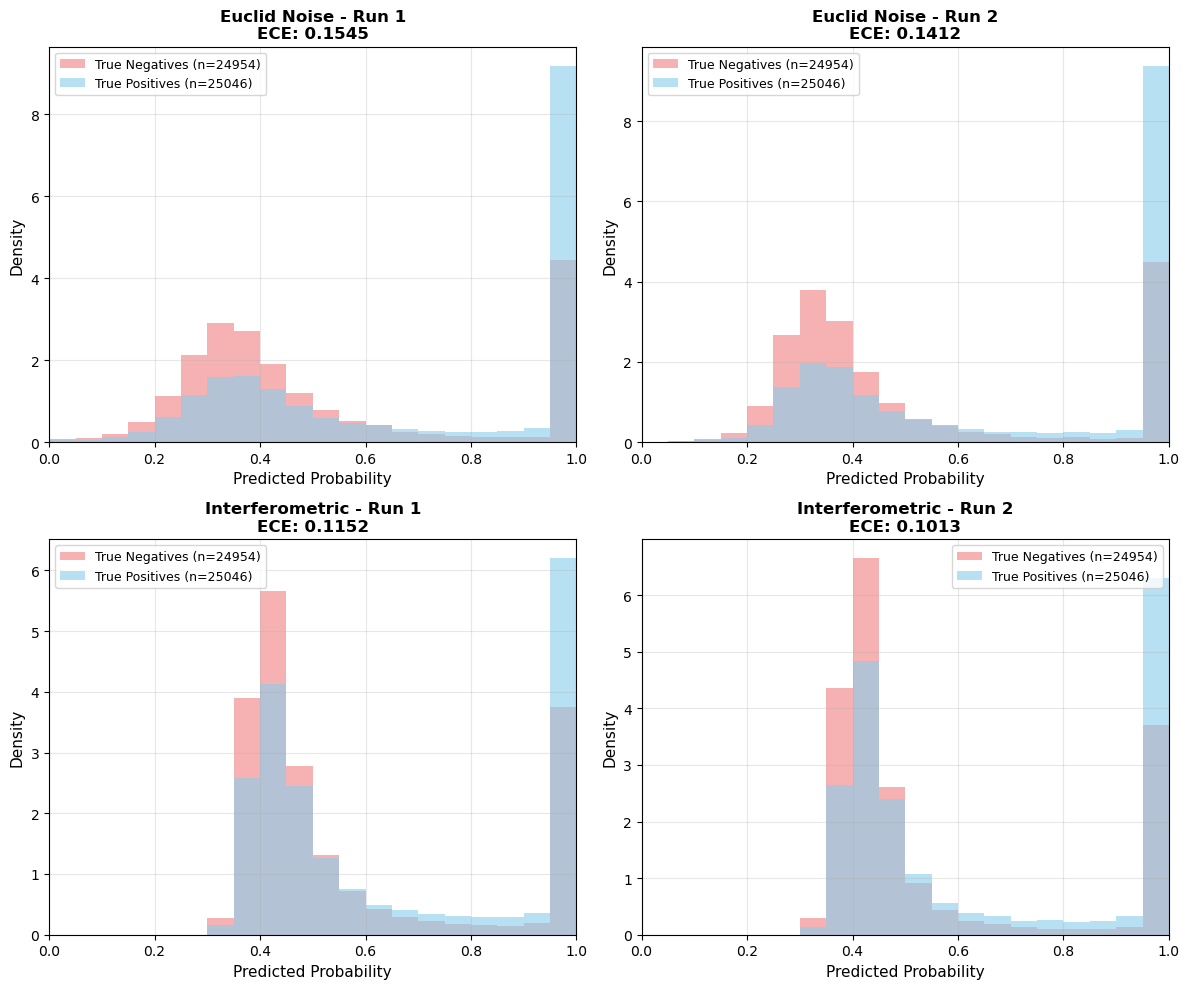

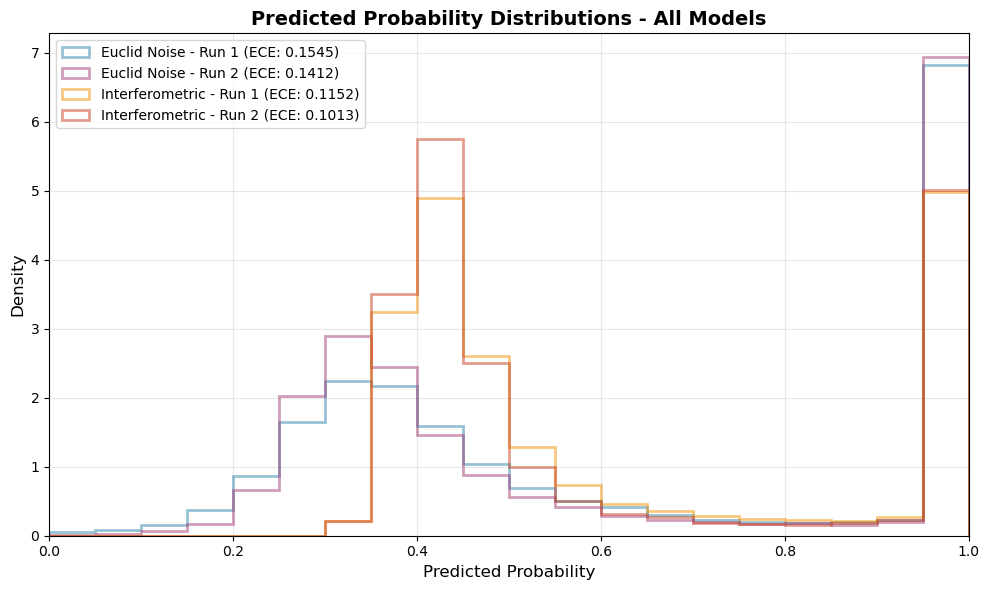

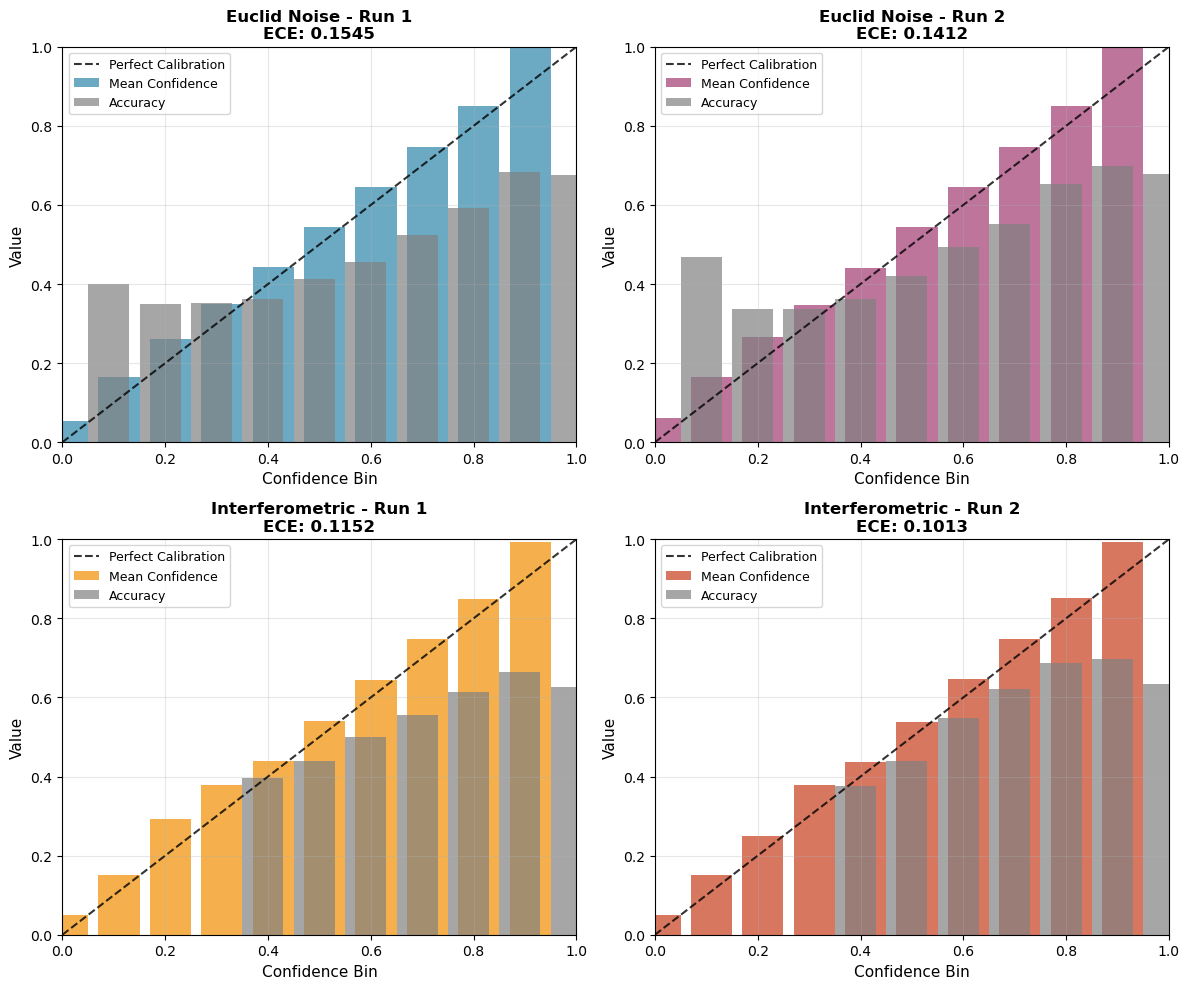

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from collections import OrderedDict
from tqdm import tqdm

# Import your modules
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import custom_dataloader
from noise_applicator.noisers.base_noiser import EuclidNoiser, OnlyInterfPSF

# Import your normalizer classes
from abc import ABC, abstractmethod

class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        pass

class Normalizer(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val
        return imgs

class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def load_model_weights(model, checkpoint_path, device):
    """Load model weights from checkpoint"""
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    
    # Remove 'module.' prefix if present
    new_state = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        new_state[name] = v
    
    # Load weights
    model.load_state_dict(new_state, strict=False)
    return model

def evaluate_model_calibration(model, dataloader, noiser, normalizer, device):
    """Evaluate a single model's calibration"""
    all_probs = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, labels = batch
            imgs = imgs.to(device)
            
            # Apply preprocessing pipeline
            imgs = noiser(imgs)
            imgs = normalizer(imgs)
            
            # Get model predictions
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Calculate calibration curve
    n_bins = 10
    fraction_of_positives, mean_predicted_value = calibration_curve(
        all_labels, all_probs, n_bins=n_bins, strategy='uniform'
    )
    
    # Calculate ECE
    ece = calculate_ece(all_labels, all_probs)
    
    return {
        'probs': all_probs,
        'labels': all_labels,
        'fraction_positives': fraction_of_positives,
        'mean_predicted': mean_predicted_value,
        'ece': ece
    }

def analyze_all_models():
    """Analyze calibration for all 4 models"""
    
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Define model configurations
    model_configs = [
        {
            'name': 'Euclid Noise - Run 1',
            'checkpoint': "../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#2E86AB',  # Blue
            'marker': 'o'
        },
        {
            'name': 'Euclid Noise - Run 2',
            'checkpoint': "../trained_classifiers/RUN2clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_23-19-17.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#A23B72',  # Purple
            'marker': 's'
        },
        {
            'name': 'Interferometric - Run 1',
            'checkpoint': "sensitivity_maps/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#F18F01',  # Orange
            'marker': '^'
        },
        {
            'name': 'Interferometric - Run 2',
            'checkpoint': "../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#C73E1D',  # Red
            'marker': 'D'
        }
    ]
    
    # Load test dataset once
    print("Loading test dataset...")
    test_dataset = NoNoiseDataset(
        "min_mass_10e8_6_test",
        grid_pixel_side=80,
        grid_width_arcsec=8.0,
        broadcasting=True,
        samples_used=50_000,
        upscaling=5,
    )
    
    dataloader = custom_dataloader(test_dataset, batch_size=256)
    
    # Store results for all models
    results = []
    
    # Evaluate each model
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        # Create and load model
        model = ResNet50(num_classes=2).to(device)
        model = load_model_weights(model, config['checkpoint'], device)
        
        # Set noiser to correct device
        config['noiser'].set_device(device)
        
        # Evaluate calibration
        result = evaluate_model_calibration(
            model, dataloader, config['noiser'], config['normalizer'], device
        )
        result['config'] = config
        results.append(result)
        
        print(f"  ECE: {result['ece']:.4f}")
    
    return results

def plot_probability_histograms(results):
    """Create histogram plots of predicted probabilities"""
    
    # Use default matplotlib style
    plt.style.use('default')
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    # Plot histogram for each model
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Separate probabilities by true labels
        probs_positive = result['probs'][result['labels'] == 1]
        probs_negative = result['probs'][result['labels'] == 0]
        
        # Create histograms
        bins = np.linspace(0, 1, 21)  # 20 bins
        ax.hist(probs_negative, bins=bins, alpha=0.6, color='lightcoral', 
                label=f'True Negatives (n={len(probs_negative)})', density=True)
        ax.hist(probs_positive, bins=bins, alpha=0.6, color='skyblue', 
                label=f'True Positives (n={len(probs_positive)})', density=True)
        
        # Styling
        ax.set_xlabel('Predicted Probability', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'{config["name"]}\nECE: {result["ece"]:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

def plot_combined_histogram(results):
    """Create a single plot comparing all models"""
    
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = np.linspace(0, 1, 21)  # 20 bins
    
    # Plot histogram for each model
    for result in results:
        config = result['config']
        ax.hist(result['probs'], bins=bins, alpha=0.5, 
                color=config['color'], label=f"{config['name']} (ECE: {result['ece']:.4f})",
                density=True, histtype='step', linewidth=2)
    
    # Styling
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Predicted Probability Distributions - All Models', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

def plot_calibration_reliability_histogram(results):
    """Create calibration reliability histogram showing bin-wise accuracy vs confidence"""
    
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Calculate bin-wise calibration data
        n_bins = 10
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
        
        bin_accuracies = []
        bin_confidences = []
        bin_counts = []
        
        for j in range(n_bins):
            bin_lower = bin_boundaries[j]
            bin_upper = bin_boundaries[j + 1]
            in_bin = (result['probs'] > bin_lower) & (result['probs'] <= bin_upper)
            
            if in_bin.sum() > 0:
                bin_accuracies.append(result['labels'][in_bin].mean())
                bin_confidences.append(result['probs'][in_bin].mean())
                bin_counts.append(in_bin.sum())
            else:
                bin_accuracies.append(0)
                bin_confidences.append(bin_centers[j])
                bin_counts.append(0)
        
        # Create bar plot
        width = 0.08
        x_pos = bin_centers
        
        # Plot confidence bars
        bars1 = ax.bar(x_pos - width/2, bin_confidences, width, 
                      label='Mean Confidence', color=config['color'], alpha=0.7)
        
        # Plot accuracy bars
        bars2 = ax.bar(x_pos + width/2, bin_accuracies, width,
                      label='Accuracy', color='gray', alpha=0.7)
        
        # Add perfect calibration line
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.8, label='Perfect Calibration')
        
        # Styling
        ax.set_xlabel('Confidence Bin', fontsize=11)
        ax.set_ylabel('Value', fontsize=11)
        ax.set_title(f'{config["name"]}\nECE: {result["ece"]:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
    
    plt.tight_layout()
    return fig

# Main execution
if __name__ == "__main__":
    print("Starting calibration analysis for all 4 models...")
    results = analyze_all_models()
    
    print("\n" + "="*50)
    print("CALIBRATION RESULTS SUMMARY")
    print("="*50)
    for result in results:
        print(f"{result['config']['name']:30s} ECE: {result['ece']:.4f}")
    
    # Create histogram visualizations
    print("\nGenerating histogram plots...")
    
    # Option 1: Individual histograms of probability distributions
    fig1 = plot_probability_histograms(results)
    plt.show()
    
    # Option 2: Combined histogram comparing all models
    fig2 = plot_combined_histogram(results)
    plt.show()
    
    # Option 3: Calibration reliability histogram (bin-wise accuracy vs confidence)
    fig3 = plot_calibration_reliability_histogram(results)
    plt.show()
    
    # Optional: Save the figures
    # fig1.savefig('probability_histograms_individual.png', dpi=300, bbox_inches='tight')
    # fig2.savefig('probability_histograms_combined.png', dpi=300, bbox_inches='tight')
    # fig3.savefig('calibration_reliability_histogram.png', dpi=300, bbox_inches='tight')

Starting calibration analysis for all 4 models...
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.
Loading test dataset...
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
1000

Evaluating Euclid Noise - Run 1...


  ECE: 0.1882

Evaluating Euclid Noise - Run 2...


  ECE: 0.1374

Evaluating Interferometric - Run 1...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1267

Evaluating Interferometric - Run 2...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1240

CALIBRATION RESULTS SUMMARY
Euclid Noise - Run 1           ECE: 0.1882
Euclid Noise - Run 2           ECE: 0.1374
Interferometric - Run 1        ECE: 0.1267
Interferometric - Run 2        ECE: 0.1240

Generating calibration histogram...


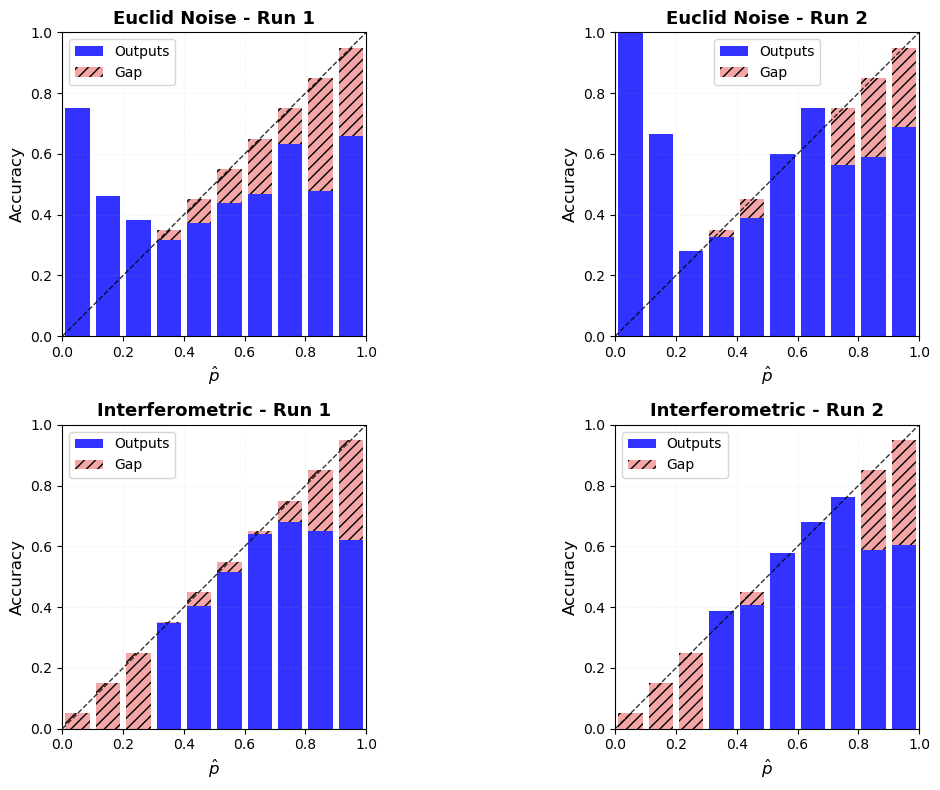

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from collections import OrderedDict
from tqdm import tqdm

# Import your modules
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import custom_dataloader
from noise_applicator.noisers.base_noiser import EuclidNoiser, OnlyInterfPSF

# Import your normalizer classes
from abc import ABC, abstractmethod

class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        pass

class Normalizer(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val
        return imgs

class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def load_model_weights(model, checkpoint_path, device):
    """Load model weights from checkpoint"""
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    
    # Remove 'module.' prefix if present
    new_state = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        new_state[name] = v
    
    # Load weights
    model.load_state_dict(new_state, strict=False)
    return model

def evaluate_model_calibration(model, dataloader, noiser, normalizer, device):
    """Evaluate a single model's calibration"""
    all_probs = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, labels = batch
            imgs = imgs.to(device)
            
            # Apply preprocessing pipeline
            imgs = noiser(imgs)
            imgs = normalizer(imgs)
            
            # Get model predictions
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Calculate calibration curve
    n_bins = 10
    fraction_of_positives, mean_predicted_value = calibration_curve(
        all_labels, all_probs, n_bins=n_bins, strategy='uniform'
    )
    
    # Calculate ECE
    ece = calculate_ece(all_labels, all_probs)
    
    return {
        'probs': all_probs,
        'labels': all_labels,
        'fraction_positives': fraction_of_positives,
        'mean_predicted': mean_predicted_value,
        'ece': ece
    }

def analyze_all_models():
    """Analyze calibration for all 4 models"""
    
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Define model configurations
    model_configs = [
        {
            'name': 'Euclid Noise - Run 1',
            'checkpoint': "../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#2E86AB',  # Blue
            'marker': 'o'
        },
        {
            'name': 'Euclid Noise - Run 2',
            'checkpoint': "../trained_classifiers/RUN2clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_23-19-17.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#A23B72',  # Purple
            'marker': 's'
        },
        {
            'name': 'Interferometric - Run 1',
            'checkpoint': "sensitivity_maps/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#F18F01',  # Orange
            'marker': '^'
        },
        {
            'name': 'Interferometric - Run 2',
            'checkpoint': "../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#C73E1D',  # Red
            'marker': 'D'
        }
    ]
    
    # Load test dataset once
    print("Loading test dataset...")
    test_dataset = NoNoiseDataset(
        "min_mass_10e8_6_test",
        grid_pixel_side=80,
        grid_width_arcsec=8.0,
        broadcasting=True,
        samples_used=1_000,
        upscaling=5,
    )
    
    dataloader = custom_dataloader(test_dataset, batch_size=256)
    
    # Store results for all models
    results = []
    
    # Evaluate each model
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        # Create and load model
        model = ResNet50(num_classes=2).to(device)
        model = load_model_weights(model, config['checkpoint'], device)
        
        # Set noiser to correct device
        config['noiser'].set_device(device)
        
        # Evaluate calibration
        result = evaluate_model_calibration(
            model, dataloader, config['noiser'], config['normalizer'], device
        )
        result['config'] = config
        results.append(result)
        
        print(f"  ECE: {result['ece']:.4f}")
    
    return results

def plot_probability_histograms(results):
    """Create histogram plots of predicted probabilities"""
    
    # Use default matplotlib style
    plt.style.use('default')
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    # Plot histogram for each model
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Separate probabilities by true labels
        probs_positive = result['probs'][result['labels'] == 1]
        probs_negative = result['probs'][result['labels'] == 0]
        
        # Create histograms
        bins = np.linspace(0, 1, 21)  # 20 bins
        ax.hist(probs_negative, bins=bins, alpha=0.6, color='lightcoral', 
                label=f'True Negatives (n={len(probs_negative)})', density=True)
        ax.hist(probs_positive, bins=bins, alpha=0.6, color='skyblue', 
                label=f'True Positives (n={len(probs_positive)})', density=True)
        
        # Styling
        ax.set_xlabel('Predicted Probability', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'{config["name"]}\nECE: {result["ece"]:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

def plot_combined_histogram(results):
    """Create a single plot comparing all models"""
    
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = np.linspace(0, 1, 21)  # 20 bins
    
    # Plot histogram for each model
    for result in results:
        config = result['config']
        ax.hist(result['probs'], bins=bins, alpha=0.5, 
                color=config['color'], label=f"{config['name']} (ECE: {result['ece']:.4f})",
                density=True, histtype='step', linewidth=2)
    
    # Styling
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Predicted Probability Distributions - All Models', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

def plot_simple_calibration_histograms(results):
    """Create simple calibration histograms like the example image"""
    
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Calculate calibration data
        n_bins = 10
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
        
        accuracies = []
        confidences = []
        
        for j in range(n_bins):
            bin_lower = bin_boundaries[j]
            bin_upper = bin_boundaries[j + 1]
            in_bin = (result['probs'] > bin_lower) & (result['probs'] <= bin_upper)
            
            if in_bin.sum() > 0:
                accuracy = result['labels'][in_bin].mean()
                confidence = result['probs'][in_bin].mean()
                accuracies.append(accuracy)
                confidences.append(confidence)
            else:
                accuracies.append(0)
                confidences.append(bin_centers[j])
        
        # Plot the bars
        width = 0.08
        
        # Blue bars for actual accuracy (outputs)
        ax.bar(bin_centers, accuracies, width, color='blue', alpha=0.8, label='Outputs')
        
        # Pink bars for the gap (difference between perfect calibration and accuracy)
        gaps = bin_centers - np.array(accuracies)  # Perfect calibration - actual accuracy
        gap_bottoms = np.array(accuracies)
        
        # Only show positive gaps (where model is under-confident)
        positive_gaps = np.maximum(gaps, 0)
        ax.bar(bin_centers, positive_gaps, width, bottom=gap_bottoms, 
               color='lightcoral', alpha=0.7, label='Gap', hatch='///')
        
        # Perfect calibration line (diagonal)
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.8, linewidth=1)
        
        # Styling
        ax.set_xlabel('$\hat p$', fontsize=12)
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_title(config["name"], fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

# Main execution
if __name__ == "__main__":
    print("Starting calibration analysis for all 4 models...")
    results = analyze_all_models()
    
    print("\n" + "="*50)
    print("CALIBRATION RESULTS SUMMARY")
    print("="*50)
    for result in results:
        print(f"{result['config']['name']:30s} ECE: {result['ece']:.4f}")
    
    # Create simple calibration histogram visualization
    print("\nGenerating calibration histogram...")
    
    # Simple calibration histograms like the example
    fig = plot_simple_calibration_histograms(results)
    plt.show()
    
    # Optional: Save the figure
    # fig.savefig('calibration_histograms.png', dpi=300, bbox_inches='tight')

Starting calibration analysis for all 4 models...
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.
Loading test dataset...
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
50000

Evaluating Euclid Noise - Run 1...


  ECE: 0.1575

Evaluating Euclid Noise - Run 2...


  ECE: 0.1444

Evaluating Interferometric - Run 1...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1106

Evaluating Interferometric - Run 2...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  ECE: 0.1017

CALIBRATION RESULTS SUMMARY
Euclid Noise - Run 1           ECE: 0.1575
Euclid Noise - Run 2           ECE: 0.1444
Interferometric - Run 1        ECE: 0.1106
Interferometric - Run 2        ECE: 0.1017

Generating calibration histogram...


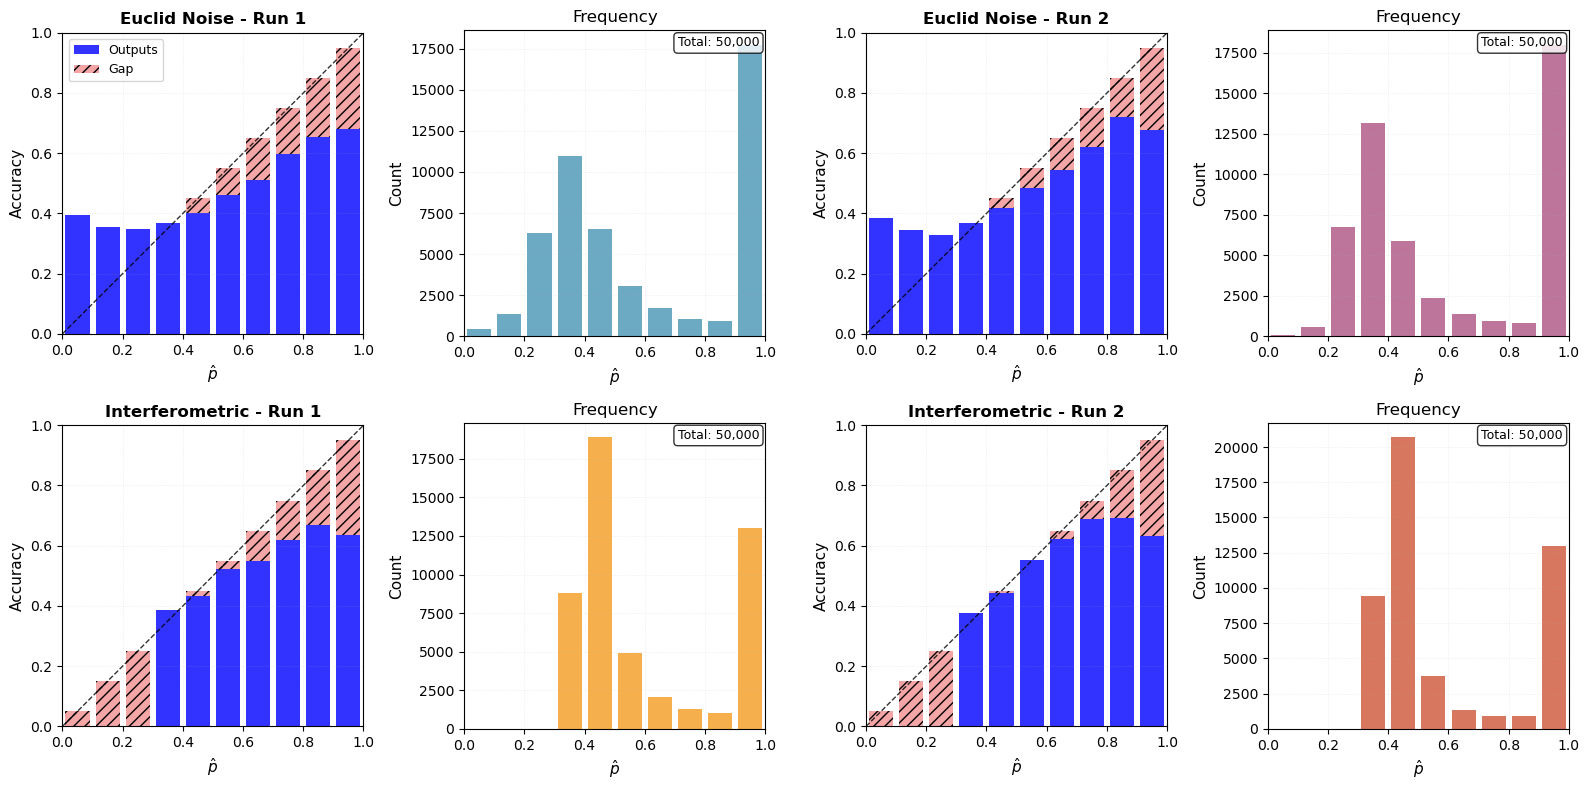

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from collections import OrderedDict
from tqdm import tqdm

# Import your modules
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import custom_dataloader
from noise_applicator.noisers.base_noiser import EuclidNoiser, OnlyInterfPSF

# Import your normalizer classes
from abc import ABC, abstractmethod

class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        pass

class Normalizer(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val
        return imgs

class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def load_model_weights(model, checkpoint_path, device):
    """Load model weights from checkpoint"""
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    
    # Remove 'module.' prefix if present
    new_state = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        new_state[name] = v
    
    # Load weights
    model.load_state_dict(new_state, strict=False)
    return model

def evaluate_model_calibration(model, dataloader, noiser, normalizer, device):
    """Evaluate a single model's calibration"""
    all_probs = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, labels = batch
            imgs = imgs.to(device)
            
            # Apply preprocessing pipeline
            imgs = noiser(imgs)
            imgs = normalizer(imgs)
            
            # Get model predictions
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Calculate calibration curve
    n_bins = 10
    fraction_of_positives, mean_predicted_value = calibration_curve(
        all_labels, all_probs, n_bins=n_bins, strategy='uniform'
    )
    
    # Calculate ECE
    ece = calculate_ece(all_labels, all_probs)
    
    return {
        'probs': all_probs,
        'labels': all_labels,
        'fraction_positives': fraction_of_positives,
        'mean_predicted': mean_predicted_value,
        'ece': ece
    }

def analyze_all_models():
    """Analyze calibration for all 4 models"""
    
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Define model configurations
    model_configs = [
        {
            'name': 'Euclid Noise - Run 1',
            'checkpoint': "../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#2E86AB',  # Blue
            'marker': 'o'
        },
        {
            'name': 'Euclid Noise - Run 2',
            'checkpoint': "../trained_classifiers/RUN2clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_23-19-17.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#A23B72',  # Purple
            'marker': 's'
        },
        {
            'name': 'Interferometric - Run 1',
            'checkpoint': "sensitivity_maps/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#F18F01',  # Orange
            'marker': '^'
        },
        {
            'name': 'Interferometric - Run 2',
            'checkpoint': "../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#C73E1D',  # Red
            'marker': 'D'
        }
    ]
    
    # Load test dataset once
    print("Loading test dataset...")
    test_dataset = NoNoiseDataset(
        "min_mass_10e8_6_test",
        grid_pixel_side=80,
        grid_width_arcsec=8.0,
        broadcasting=True,
        samples_used=50_000,
        upscaling=5,
    )
    
    dataloader = custom_dataloader(test_dataset, batch_size=256)
    
    # Store results for all models
    results = []
    
    # Evaluate each model
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        # Create and load model
        model = ResNet50(num_classes=2).to(device)
        model = load_model_weights(model, config['checkpoint'], device)
        
        # Set noiser to correct device
        config['noiser'].set_device(device)
        
        # Evaluate calibration
        result = evaluate_model_calibration(
            model, dataloader, config['noiser'], config['normalizer'], device
        )
        result['config'] = config
        results.append(result)
        
        print(f"  ECE: {result['ece']:.4f}")
    
    return results

def plot_probability_histograms(results):
    """Create histogram plots of predicted probabilities"""
    
    # Use default matplotlib style
    plt.style.use('default')
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    # Plot histogram for each model
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Separate probabilities by true labels
        probs_positive = result['probs'][result['labels'] == 1]
        probs_negative = result['probs'][result['labels'] == 0]
        
        # Create histograms
        bins = np.linspace(0, 1, 21)  # 20 bins
        ax.hist(probs_negative, bins=bins, alpha=0.6, color='lightcoral', 
                label=f'True Negatives (n={len(probs_negative)})', density=True)
        ax.hist(probs_positive, bins=bins, alpha=0.6, color='skyblue', 
                label=f'True Positives (n={len(probs_positive)})', density=True)
        
        # Styling
        ax.set_xlabel('Predicted Probability', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'{config["name"]}\nECE: {result["ece"]:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

def plot_combined_histogram(results):
    """Create a single plot comparing all models"""
    
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = np.linspace(0, 1, 21)  # 20 bins
    
    # Plot histogram for each model
    for result in results:
        config = result['config']
        ax.hist(result['probs'], bins=bins, alpha=0.5, 
                color=config['color'], label=f"{config['name']} (ECE: {result['ece']:.4f})",
                density=True, histtype='step', linewidth=2)
    
    # Styling
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Predicted Probability Distributions - All Models', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

def plot_simple_calibration_histograms(results):
    """Create simple calibration histograms with frequency histograms on the right"""
    
    plt.style.use('default')
    fig = plt.figure(figsize=(16, 8))
    
    for i, result in enumerate(results):
        config = result['config']
        
        # Create subplot with 2 columns for each model
        ax_cal = plt.subplot(2, 4, i*2 + 1)  # Calibration plot
        ax_freq = plt.subplot(2, 4, i*2 + 2)  # Frequency plot
        
        # Calculate calibration data
        n_bins = 10
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
        
        accuracies = []
        confidences = []
        bin_counts = []
        
        for j in range(n_bins):
            bin_lower = bin_boundaries[j]
            bin_upper = bin_boundaries[j + 1]
            in_bin = (result['probs'] > bin_lower) & (result['probs'] <= bin_upper)
            
            count = in_bin.sum()
            bin_counts.append(count)
            
            if count > 0:
                accuracy = result['labels'][in_bin].mean()
                confidence = result['probs'][in_bin].mean()
                accuracies.append(accuracy)
                confidences.append(confidence)
            else:
                accuracies.append(0)
                confidences.append(bin_centers[j])
        
        # CALIBRATION PLOT (left)
        width = 0.08
        
        # Blue bars for actual accuracy (outputs)
        ax_cal.bar(bin_centers, accuracies, width, color='blue', alpha=0.8, label='Outputs')
        
        # Pink bars for the gap (difference between perfect calibration and accuracy)
        gaps = bin_centers - np.array(accuracies)  # Perfect calibration - actual accuracy
        gap_bottoms = np.array(accuracies)
        
        # Only show positive gaps (where model is under-confident)
        positive_gaps = np.maximum(gaps, 0)
        ax_cal.bar(bin_centers, positive_gaps, width, bottom=gap_bottoms, 
                   color='lightcoral', alpha=0.7, label='Gap', hatch='///')
        
        # Perfect calibration line (diagonal)
        ax_cal.plot([0, 1], [0, 1], 'k--', alpha=0.8, linewidth=1)
        
        # Calibration plot styling
        ax_cal.set_xlabel('$\hat p$', fontsize=11)
        ax_cal.set_ylabel('Accuracy', fontsize=11)
        ax_cal.set_title(config["name"], fontsize=12, fontweight='bold')
        if i == 0:  # Only show legend on first plot
            ax_cal.legend(fontsize=9)
        ax_cal.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        ax_cal.set_xlim([0, 1])
        ax_cal.set_ylim([0, 1])
        ax_cal.set_aspect('equal')
        
        # FREQUENCY PLOT (right)
        ax_freq.bar(bin_centers, bin_counts, width, color=config['color'], alpha=0.7)
        
        # Frequency plot styling
        ax_freq.set_xlabel('$\hat p$', fontsize=11)
        ax_freq.set_ylabel('Count', fontsize=11)
        ax_freq.set_title('Frequency', fontsize=12)
        ax_freq.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        ax_freq.set_xlim([0, 1])
        
        # Add text showing total samples
        total_samples = len(result['probs'])
        ax_freq.text(0.98, 0.98, f'Total: {total_samples:,}', 
                    transform=ax_freq.transAxes, fontsize=9,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return fig

# Main execution
if __name__ == "__main__":
    print("Starting calibration analysis for all 4 models...")
    results = analyze_all_models()
    
    print("\n" + "="*50)
    print("CALIBRATION RESULTS SUMMARY")
    print("="*50)
    for result in results:
        print(f"{result['config']['name']:30s} ECE: {result['ece']:.4f}")
    
    # Create simple calibration histogram visualization
    print("\nGenerating calibration histogram...")
    
    # Simple calibration histograms like the example
    fig = plot_simple_calibration_histograms(results)
    plt.show()
    
    # Optional: Save the figure
    # fig.savefig('calibration_histograms.png', dpi=300, bbox_inches='tight')

Starting ROC analysis for all 4 models...
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.
Loading test dataset...
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
50000

Evaluating Euclid Noise - Run 1...


  AUC: 0.6519

Evaluating Euclid Noise - Run 2...


  AUC: 0.6570

Evaluating Interferometric - Run 1...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  AUC: 0.6057

Evaluating Interferometric - Run 2...
The PthPSF is loaded as it is. All the physical considerations must be done building it.


  AUC: 0.6155

ROC RESULTS SUMMARY
Euclid Noise - Run 1           AUC: 0.6519
Euclid Noise - Run 2           AUC: 0.6570
Interferometric - Run 1        AUC: 0.6057
Interferometric - Run 2        AUC: 0.6155

Generating ROC plots...


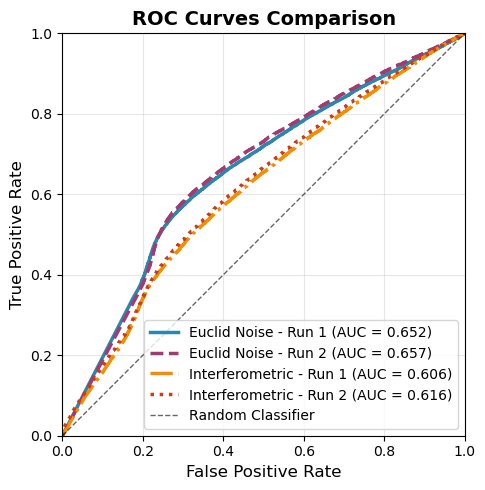

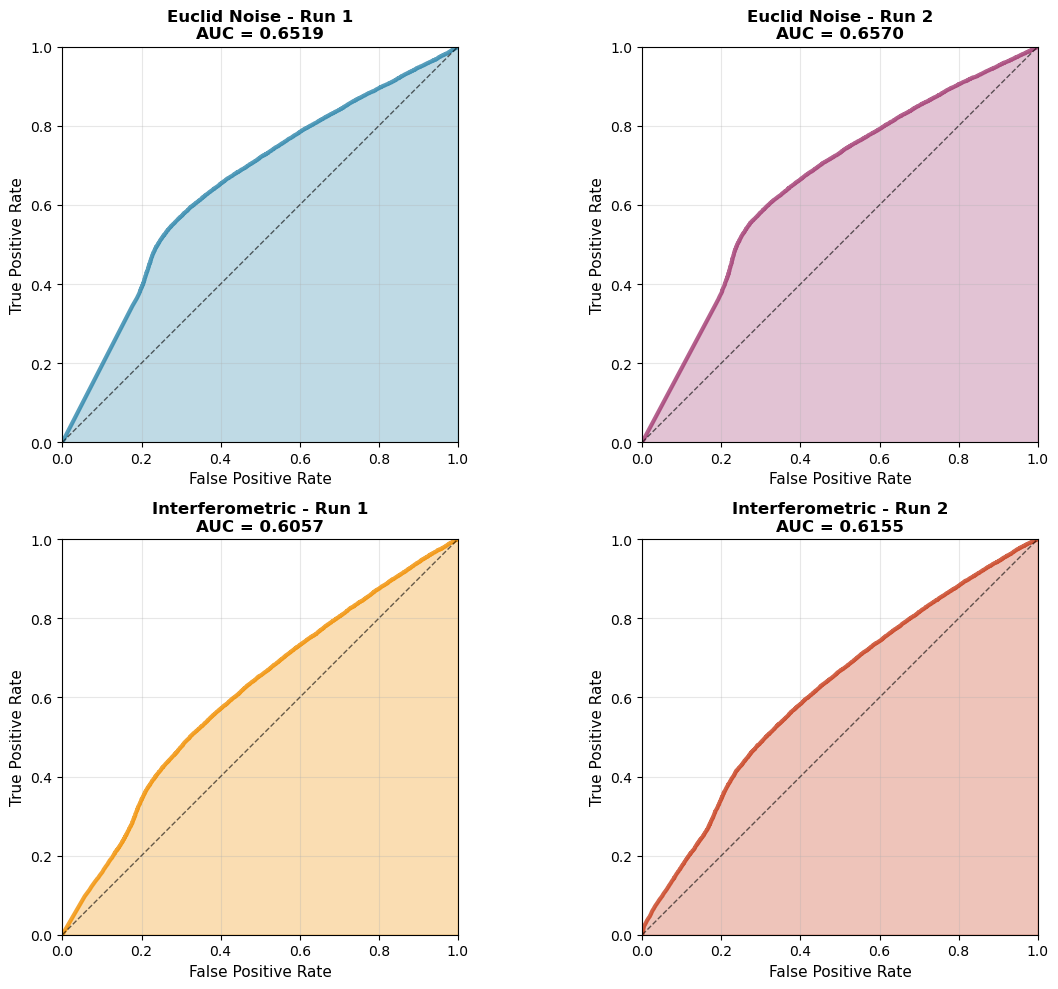

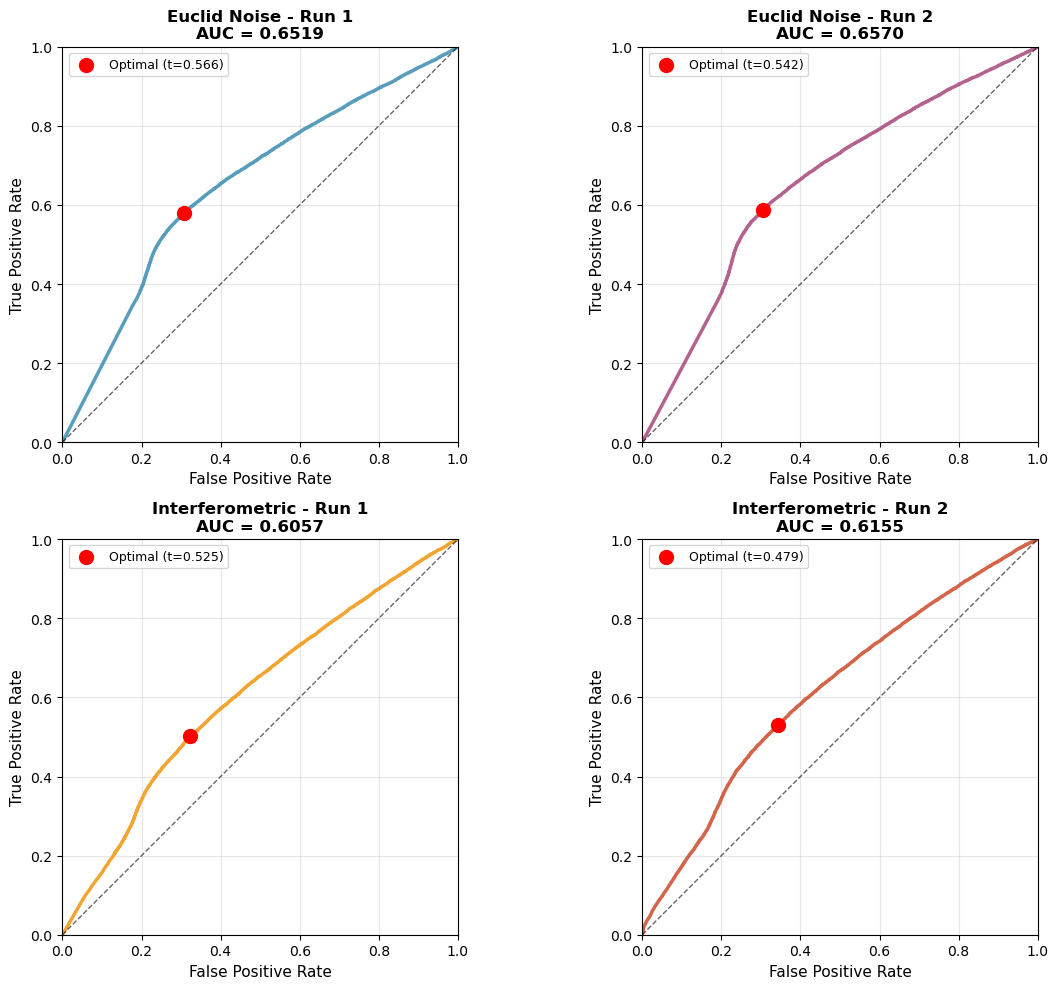

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from collections import OrderedDict
from tqdm import tqdm

# Import your modules
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from deep_learning.NN_datasets.dataloaders import custom_dataloader
from noise_applicator.noisers.base_noiser import EuclidNoiser, OnlyInterfPSF

# Import your normalizer classes
from abc import ABC, abstractmethod

class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        pass

class Normalizer(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val
        return imgs

class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs

def load_model_weights(model, checkpoint_path, device):
    """Load model weights from checkpoint"""
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    
    # Remove 'module.' prefix if present
    new_state = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        new_state[name] = v
    
    # Load weights
    model.load_state_dict(new_state, strict=False)
    return model

def evaluate_model_roc(model, dataloader, noiser, normalizer, device):
    """Evaluate a single model and return predictions for ROC analysis"""
    all_probs = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, labels = batch
            imgs = imgs.to(device)
            
            # Apply preprocessing pipeline
            imgs = noiser(imgs)
            imgs = normalizer(imgs)
            
            # Get model predictions
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    return {
        'probs': all_probs,
        'labels': all_labels,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'auc': roc_auc
    }

def analyze_all_models_roc():
    """Analyze ROC curves for all 4 models"""
    
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Define model configurations
    model_configs = [
        {
            'name': 'Euclid Noise - Run 1',
            'checkpoint': "../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#2E86AB',  # Blue
            'linestyle': '-'
        },
        {
            'name': 'Euclid Noise - Run 2',
            'checkpoint': "../trained_classifiers/RUN2clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_23-19-17.pth",
            'noiser': EuclidNoiser(),
            'normalizer': Normalizer(),
            'color': '#A23B72',  # Purple
            'linestyle': '--'
        },
        {
            'name': 'Interferometric - Run 1',
            'checkpoint': "sensitivity_maps/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#F18F01',  # Orange
            'linestyle': '-.'
        },
        {
            'name': 'Interferometric - Run 2',
            'checkpoint': "../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth",
            'noiser': OnlyInterfPSF(),
            'normalizer': NormalizerInterf(),
            'color': '#C73E1D',  # Red
            'linestyle': ':'
        }
    ]
    
    # Load test dataset once
    print("Loading test dataset...")
    test_dataset = NoNoiseDataset(
        "min_mass_10e8_6_test",
        grid_pixel_side=80,
        grid_width_arcsec=8.0,
        broadcasting=True,
        samples_used=50_000,
        upscaling=5,
    )
    
    dataloader = custom_dataloader(test_dataset, batch_size=256)
    
    # Store results for all models
    results = []
    
    # Evaluate each model
    for config in model_configs:
        print(f"\nEvaluating {config['name']}...")
        
        # Create and load model
        model = ResNet50(num_classes=2).to(device)
        model = load_model_weights(model, config['checkpoint'], device)
        
        # Set noiser to correct device
        config['noiser'].set_device(device)
        
        # Evaluate ROC
        result = evaluate_model_roc(
            model, dataloader, config['noiser'], config['normalizer'], device
        )
        result['config'] = config
        results.append(result)
        
        print(f"  AUC: {result['auc']:.4f}")
    
    return results

def plot_roc_curves(results):
    """Plot ROC curves for all models"""
    
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Plot ROC curve for each model
    for result in results:
        config = result['config']
        ax.plot(result['fpr'], result['tpr'], 
                color=config['color'], 
                linestyle=config['linestyle'],
                linewidth=2.5,
                label=f"{config['name']} (AUC = {result['auc']:.3f})")
    
    # Plot diagonal line (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1, label='Random Classifier')
    
    # Styling
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

def plot_roc_curves_individual(results):
    """Plot individual ROC curves in subplots"""
    
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Plot ROC curve
        ax.plot(result['fpr'], result['tpr'], 
                color=config['color'], linewidth=3, alpha=0.8)
        
        # Fill area under curve
        ax.fill_between(result['fpr'], result['tpr'], alpha=0.3, color=config['color'])
        
        # Plot diagonal line
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1)
        
        # Styling
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'{config["name"]}\nAUC = {result["auc"]:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

def plot_threshold_analysis(results):
    """Plot threshold analysis showing optimal operating points"""
    
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, result in enumerate(results):
        config = result['config']
        ax = axes[i]
        
        # Calculate Youden's J statistic (TPR - FPR) to find optimal threshold
        j_scores = result['tpr'] - result['fpr']
        optimal_idx = np.argmax(j_scores)
        optimal_threshold = result['thresholds'][optimal_idx]
        optimal_tpr = result['tpr'][optimal_idx]
        optimal_fpr = result['fpr'][optimal_idx]
        
        # Plot ROC curve
        ax.plot(result['fpr'], result['tpr'], 
                color=config['color'], linewidth=2.5, alpha=0.8)
        
        # Highlight optimal point
        ax.scatter(optimal_fpr, optimal_tpr, color='red', s=100, zorder=5,
                  label=f'Optimal (t={optimal_threshold:.3f})')
        
        # Plot diagonal
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1)
        
        # Styling
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'{config["name"]}\nAUC = {result["auc"]:.4f}', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

# Main execution
if __name__ == "__main__":
    print("Starting ROC analysis for all 4 models...")
    results = analyze_all_models_roc()
    
    print("\n" + "="*50)
    print("ROC RESULTS SUMMARY")
    print("="*50)
    for result in results:
        print(f"{result['config']['name']:30s} AUC: {result['auc']:.4f}")
    
    # Create ROC visualizations
    print("\nGenerating ROC plots...")
    
    # Option 1: Combined ROC curves
    fig1 = plot_roc_curves(results)
    plt.show()
    
    # Option 2: Individual ROC curves with filled areas
    fig2 = plot_roc_curves_individual(results)
    plt.show()
    
    # Option 3: ROC curves with optimal threshold points
    fig3 = plot_threshold_analysis(results)
    plt.show()
    
    # Optional: Save the figures
    # fig1.savefig('roc_curves_combined.png', dpi=300, bbox_inches='tight')
    # fig2.savefig('roc_curves_individual.png', dpi=300, bbox_inches='tight')
    # fig3.savefig('roc_curves_with_thresholds.png', dpi=300, bbox_inches='tight')